# Exercise — Handwritten digit classification with a DNN, CNN, and SNN
(C) Pietro Vischia, 2025  

Prepared with assistance from CODEX with GPT-5.6.

In this exercise we compare three neural-network families on **MNIST handwritten digits**:

1. a fully connected deep neural network (DNN) in PyTorch;
2. a convolutional neural network (CNN) in PyTorch;
3. a spiking neural network (SNN) in `snntorch`.

The notebook is deliberately heavily commented. Read the comments, run the cells in order, and answer the **Questions** as you go. The final comparison uses **multiclass one-vs-rest micro-average ROC curves**, superimposed in one figure.

> **Learning goals.** Explain why a CNN has a better inductive bias for images; describe rate coding and leaky integrate-and-fire neurons; train all models under a common protocol; and interpret ROC/AUC for multiclass classification.

## 0. Setup

If needed, uncomment the installation command. On Google Colab, select a GPU runtime first. `snntorch` supplies differentiable spiking-neuron modules; scikit-learn supplies ROC utilities.

In [1]:
import copy
import random
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import snntorch as snn
from snntorch import spikegen, surrogate

from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm

# Reproducibility: deterministic seeds make comparisons easier to discuss.
# Exact bit-for-bit equality can still depend on hardware and library versions.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Experimental configuration

The default subset makes the exercise finish in a reasonable lab session. Set `FAST_MODE = False` for the complete 60,000-image training set. The test set is kept intact so evaluation remains stable.

**Question 1.** Is the comparison perfectly fair if every model uses the same number of epochs but has a different number of parameters or a different cost per forward pass? Suggest two alternative compute budgets.

In [2]:
FAST_MODE = True

BATCH_SIZE = 128
EPOCHS = 3 if FAST_MODE else 5
TRAIN_SAMPLES = 15_000 if FAST_MODE else 60_000
LEARNING_RATE = 1e-3

# Number of simulation time steps for the SNN. More steps provide a longer
# observation window but make training and inference proportionally slower.
NUM_STEPS = 20
NUM_CLASSES = 10

print({"epochs": EPOCHS, "train_samples": TRAIN_SAMPLES,
       "batch_size": BATCH_SIZE, "SNN_steps": NUM_STEPS})

{'epochs': 3, 'train_samples': 15000, 'batch_size': 128, 'SNN_steps': 20}


## 2. Load and inspect MNIST

MNIST contains grayscale 28×28 images and labels 0–9. `ToTensor()` maps pixel values from integers in `[0,255]` to floating-point values in `[0,1]`. We intentionally do not standardize further: for the SNN these values can be interpreted directly as spike probabilities during rate coding.

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████| 9.91M/9.91M [00:01<00:00, 7.21MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|███████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 312kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 2.83MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|███████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 961kB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



Image batch: torch.Size([128, 1, 28, 28]) Label batch: torch.Size([128])


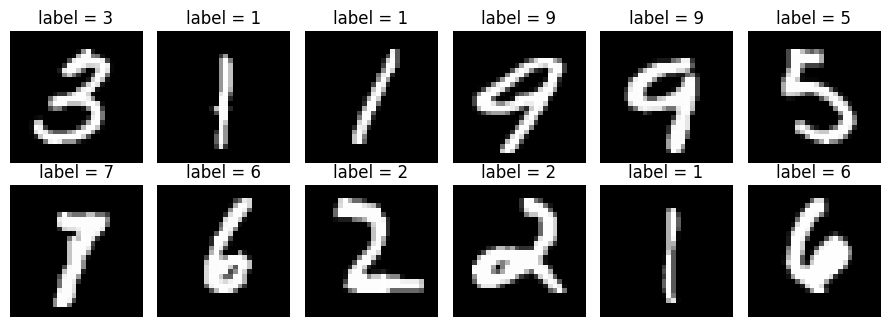

In [3]:
transform = transforms.ToTensor()
train_full = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Use a seeded random subset rather than the first N examples. This avoids a
# hidden ordering assumption and makes the subset reproducible.
generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(train_full), generator=generator)[:TRAIN_SAMPLES]
train_dataset = Subset(train_full, indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=torch.cuda.is_available())

images, labels = next(iter(train_loader))
print("Image batch:", images.shape, "Label batch:", labels.shape)

fig, axes = plt.subplots(2, 6, figsize=(9, 3.3))
for ax, image, label in zip(axes.ravel(), images[:12], labels[:12]):
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_title(f"label = {label.item()}")
    ax.axis("off")
plt.tight_layout()

## 3. Model A — fully connected DNN

The DNN first flattens each image, discarding the explicit 2-D neighborhood structure. Every pixel then connects to every unit in the first hidden layer. This is flexible, but it does not encode translation-related image structure.

**Question 2.** Compute the number of weights in the first linear layer. Why might this model be more prone to overfitting than a small CNN?

In [4]:
class FullyConnectedDNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),                 # (B, 1, 28, 28) -> (B, 784)
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.20),             # active only during model.train()
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, NUM_CLASSES),  # raw scores (logits), not probabilities
        )

    def forward(self, x):
        return self.network(x)

## 4. Model B — convolutional neural network

Convolutions reuse small filters across locations. This **weight sharing** reduces the parameter count and expresses a useful image prior: the same local pattern can matter wherever it appears. Pooling reduces spatial resolution and increases tolerance to small shifts.

In [5]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # 28x28 -> 28x28
            nn.ReLU(),
            nn.MaxPool2d(2),                            # 28x28 -> 14x14
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                            # 14x14 -> 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, NUM_CLASSES),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

## 5. Model C — spiking neural network

We use leaky integrate-and-fire (LIF) neurons. Their membrane potential accumulates input, leaks over time, and emits a spike after crossing a threshold. Because the hard spike function has zero/undefined derivatives, training uses a **surrogate gradient** during backpropagation.

Input pixels are converted to Bernoulli spike trains by rate coding: a brighter pixel has a higher probability of producing a spike at every time step. The output prediction is based on output spike counts.

**Question 3.** What information is lost when a static image is converted to a finite random spike train? What happens as `NUM_STEPS` increases?

In [6]:
class SpikingNN(nn.Module):
    def __init__(self, num_steps=NUM_STEPS, beta=0.95):
        super().__init__()
        self.num_steps = num_steps
        spike_grad = surrogate.fast_sigmoid(slope=25)

        self.fc1 = nn.Linear(28 * 28, 256)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.fc2 = nn.Linear(256, NUM_CLASSES)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        # Rate encoding returns (time, batch, channel, height, width).
        # Stochastic encoding is used in both training and evaluation; for a
        # lower-variance final estimate one could average several SNN passes.
        spike_input = spikegen.rate(x, num_steps=self.num_steps)
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        output_spikes = []

        for step in range(self.num_steps):
            current1 = self.fc1(spike_input[step].flatten(1))
            spk1, mem1 = self.lif1(current1, mem1)
            current2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(current2, mem2)
            output_spikes.append(spk2)

        # Shape: (time, batch, classes). Spike count is an evidence score.
        return torch.stack(output_spikes, dim=0)

## 6. Shared training and evaluation utilities

For conventional networks, cross-entropy acts on logits. For the SNN, we sum output spikes over time and apply cross-entropy to those class-wise counts. This is a simple pedagogical loss; `snntorch.functional` also provides spike-specific alternatives.

In [7]:
def parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def class_scores(model, x, is_snn=False):
    """Return one score per class, suitable for loss, prediction, and ROC."""
    output = model(x)
    return output.sum(dim=0) if is_snn else output

def train_one_model(model, train_loader, epochs, lr, is_snn=False):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        seen = 0

        progress = tqdm(train_loader, desc=f"epoch {epoch + 1}/{epochs}", leave=False)
        for x, y in progress:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            scores = class_scores(model, x, is_snn=is_snn)
            loss = criterion(scores, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            correct += (scores.argmax(1) == y).sum().item()
            seen += x.size(0)
            progress.set_postfix(loss=f"{running_loss / seen:.3f}",
                                 acc=f"{correct / seen:.3f}")

        history.append({"loss": running_loss / seen, "accuracy": correct / seen})
        print(f"epoch {epoch + 1}: loss={history[-1]['loss']:.4f}, "
              f"training accuracy={history[-1]['accuracy']:.4f}")
    return history

@torch.inference_mode()
def evaluate_scores(model, loader, is_snn=False):
    """Collect labels, probabilities, predictions, accuracy, and elapsed time."""
    model.eval()  # disables dropout; essential for reproducible DNN/CNN inference
    all_labels, all_probabilities = [], []
    start = time.perf_counter()

    for x, y in tqdm(loader, desc="evaluation", leave=False):
        x = x.to(device)
        scores = class_scores(model, x, is_snn=is_snn)

        # Softmax creates comparable within-model class scores in [0,1]. ROC
        # needs rankings, not calibrated probabilities, but these are intuitive.
        probabilities = torch.softmax(scores, dim=1)
        all_labels.append(y.numpy())
        all_probabilities.append(probabilities.cpu().numpy())

    elapsed = time.perf_counter() - start
    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probabilities)
    y_pred = y_prob.argmax(axis=1)
    return y_true, y_prob, accuracy_score(y_true, y_pred), elapsed

## 7. Instantiate and compare model sizes

Parameter count is only one notion of complexity. The SNN repeatedly executes its layers for `NUM_STEPS` steps, so similar parameter counts do not imply similar latency or energy use on ordinary hardware.

In [8]:
models = {
    "DNN": FullyConnectedDNN(),
    "CNN": SmallCNN(),
    "SNN": SpikingNN(),
}

for name, model in models.items():
    print(f"{name}: {parameter_count(model):,} trainable parameters")

DNN: 235,146 trainable parameters
CNN: 206,922 trainable parameters
SNN: 203,530 trainable parameters


## 8. Train all three models

All models see the same training subset, number of epochs, optimizer family, and base learning rate. This is transparent but not necessarily optimal for every architecture. A rigorous benchmark would tune each model on a separate validation set and repeat training over multiple random seeds.

> **Practical note:** SNN training is slower because each batch is simulated over multiple time steps.

In [ ]:
histories = {}
for name, model in models.items():
    print(f"\n{'=' * 20} Training {name} {'=' * 20}")
    histories[name] = train_one_model(
        model, train_loader, epochs=EPOCHS, lr=LEARNING_RATE,
        is_snn=(name == "SNN")
    )


==================== Training DNN ====================


epoch 1/3:   0%|          | 0/118 [00:00<?, ?it/s]

epoch 1: loss=0.7680, training accuracy=0.7705


epoch 2/3:   0%|          | 0/118 [00:00<?, ?it/s]

epoch 2: loss=0.3066, training accuracy=0.9099


...

epoch 2/3:   0%|          | 0/118 [00:00<?, ?it/s]

epoch 2: loss=0.2289, training accuracy=0.9320


epoch 3/3:   0%|          | 0/118 [00:00<?, ?it/s]

epoch 3: loss=0.1514, training accuracy=0.9553

==================== Training SNN ====================


epoch 1/3:   0%|          | 0/118 [00:00<?, ?it/s]

## 9. Evaluate on the common test set

Accuracy answers “how often is the top-ranked class correct?” ROC instead studies the ranking of positive versus negative examples across thresholds. The timing below is hardware- and implementation-dependent; it is illustrative, not an energy benchmark.

In [ ]:
results = {}
for name, model in models.items():
    y_true, y_prob, accuracy, seconds = evaluate_scores(
        model, test_loader, is_snn=(name == "SNN")
    )
    results[name] = {"y_true": y_true, "y_prob": y_prob,
                     "accuracy": accuracy, "seconds": seconds}
    print(f"{name}: test accuracy={accuracy:.4f}, evaluation time={seconds:.2f}s")

## 10. Multiclass ROC: one-vs-rest micro-average

ROC is fundamentally binary. For ten classes, we first binarize each label into ten one-vs-rest indicators. The **micro-average** then flattens all example–class decisions into one long binary problem. This weights every example–class pair equally and is dominated by common decisions.

The positive class in each binary task is “this example belongs to digit *k*”; the remaining nine digits form the negative class. A random ranking has AUC near 0.5; perfect ranking has AUC 1.0.

**Question 4.** Why can ROC-AUC look excellent in one-vs-rest multiclass problems even when some classification errors remain? Compare the class balance of each binary task.

In [ ]:
# The labels must be identical because all models used the same unshuffled test set.
y_true = results["DNN"]["y_true"]
assert all(np.array_equal(y_true, results[name]["y_true"]) for name in models)
y_binary = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

roc_results = {}
for name in models:
    # Flattening implements the micro-average across samples and classes.
    fpr, tpr, thresholds = roc_curve(y_binary.ravel(), results[name]["y_prob"].ravel())
    roc_results[name] = {"fpr": fpr, "tpr": tpr, "auc": auc(fpr, tpr)}
    print(f"{name}: micro-average ROC-AUC = {roc_results[name]['auc']:.4f}")

## 11. Final result — superimposed ROC curves

This is the requested final comparison. Interpret small differences cautiously: the SNN encoding is stochastic, and all results come from a single seed and a short training schedule.

In [ ]:
plt.figure(figsize=(8, 6))
colors = {"DNN": "tab:blue", "CNN": "tab:orange", "SNN": "tab:green"}

for name in ["DNN", "CNN", "SNN"]:
    r = roc_results[name]
    plt.plot(r["fpr"], r["tpr"], linewidth=2.2, color=colors[name],
             label=f"{name} (micro-AUC = {r['auc']:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random ranking")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("MNIST multiclass ROC comparison (one-vs-rest, micro-average)")
plt.xlim(0, 1)
plt.ylim(0, 1.01)
plt.grid(alpha=0.25)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 12. Discussion and extension tasks

1. **Architecture:** Explain why the CNN usually performs strongly on images even with a modest training budget.
2. **SNN representation:** Plot the rate-coded spike train of one bright pixel and one dark pixel. Relate empirical firing rate to pixel intensity.
3. **Time/accuracy trade-off:** Repeat SNN training with `NUM_STEPS` in `{5, 10, 20, 40}`. Plot accuracy and evaluation time.
4. **Per-class behavior:** Compute ten one-vs-rest ROC curves for each model. Which digits are most difficult to distinguish?
5. **Better experimental design:** Add a validation split, tune hyperparameters separately, repeat at least three seeds, and report mean ± standard deviation.
6. **Calibration:** Reliability and ROC answer different questions. Compare expected calibration error or a reliability diagram for the three score outputs.

### Takeaway

The DNN treats pixels as an unstructured vector; the CNN exploits spatial locality and weight sharing; the SNN represents and processes information through events over time. ROC-AUC compares score rankings, while accuracy compares final argmax decisions. Neither metric alone settles questions of compute efficiency, energy, robustness, or suitability for neuromorphic hardware.